## All Packages needed

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import scipy.ndimage
from scipy import misc
from glob import glob
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import skimage
import imageio
import seaborn as sns
from PIL import Image
import glob
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

# Data loading & inspection
## Getting shape of CSV file
## And summary of data types

In [32]:
#Getting a summary of the number of images and the different class IDs

df = pd.read_csv('labels_train.csv')
df.shape
df


,file_name,class_id
0,img_4358977458434011046.jpg,1
1,img_5224016757187192130.jpg,2
2,img_3065202206106254707.jpg,2
3,img_6304894865561547174.jpg,1
4,img_3371338542810939877.jpg,2
...,...,...
4667,img_6661311872293090412.jpg,2
4668,img_3844568579349757418.jpg,1
4669,img_9145812369383814369.jpg,1
4670,img_1311393330250392648.jpg,1


In [33]:
# Need to create folders for each X-ray type to store the images
types = df['class_id'].unique()
print(types)

[1 2 0]


# Feature-level analysis

## There are 3 image classes:

Class 0: no disease

Class 1: bacterial pneumonia

Class 2: viral pneumonia

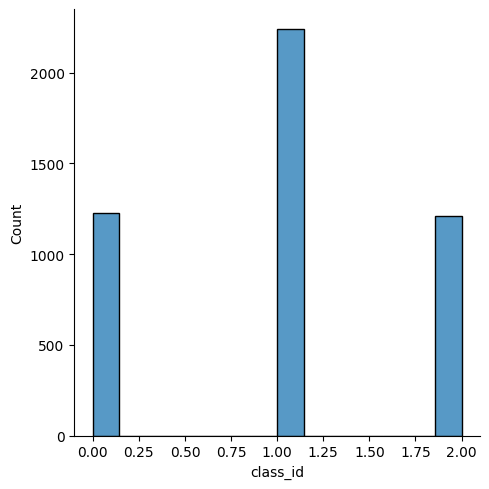

In [34]:
#visualization displot of the different classes and their image counts

sns.displot(df['class_id'])
plt.show()

## Discuss any class imbalance, possible bias, noise

There are many more bacterial image X-rays of pneumonia than there are normal and viral X-rays. We can fix this class imbalance with class weights.

## Missing values, outliers, duplicates

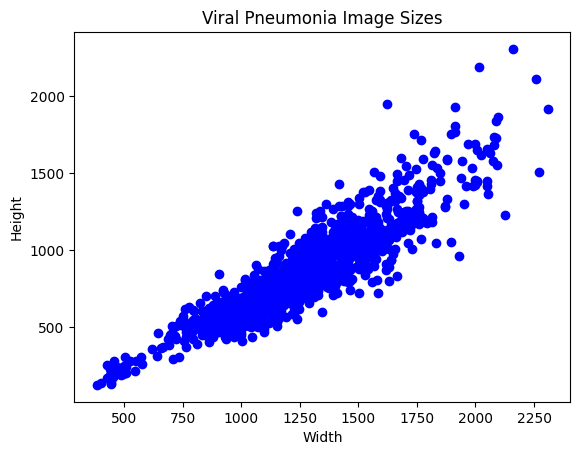

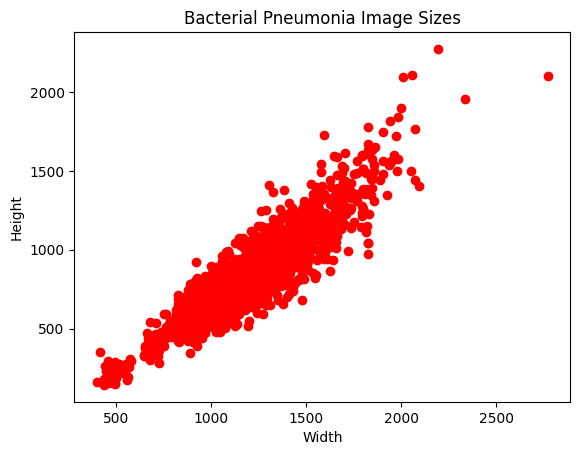

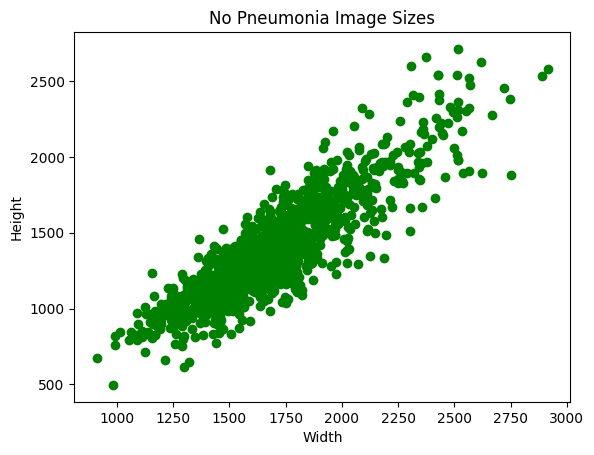

In [37]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Class folders inside final_train
base_dir = 'final_train'
classes = ['viral_pneumonia', 'bacterial_pneumonia', 'no_pneumonia']

vp_w, vp_h = [], []
bp_w, bp_h = [], []
np_w, np_h = [], []

for label in classes:
    folder_path = os.path.join(base_dir, label)
    
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        image = Image.open(image_path)
        w, h = image.size

        if label == 'viral_pneumonia':
            vp_w.append(w)
            vp_h.append(h)
        elif label == 'bacterial_pneumonia':
            bp_w.append(w)
            bp_h.append(h)
        else:
            np_w.append(w)
            np_h.append(h)

# Plot viral pneumonia sizes
plt.scatter(vp_w, vp_h, color='blue')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Viral Pneumonia Image Sizes")
plt.show()

# Plot bacterial pneumonia sizes
plt.scatter(bp_w, bp_h, color='red')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Bacterial Pneumonia Image Sizes")
plt.show()

# Plot no pneumonia sizes
plt.scatter(np_w, np_h, color='green')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("No Pneumonia Image Sizes")
plt.show()


In [38]:
#This shows if there are any missing values in the 2 columns provided with the CSV file
df.isnull().sum()

file_name    0
class_id     0
dtype: int64

## Calculating class weights

This is to compensate for the class imbalance seen with the histogram.

In [39]:
# sizes of each class
classes = df['class_id'].unique()
total_images = df.shape[0]
class_weights = {}
class_frequencies = []

for c in classes:
    class_weights[c] = df['class_id'].value_counts().get(c, 0)
    class_frequencies.append(class_weights[c]/total_images)
    class_weights[c] = class_weights[c]/total_images

class_median = np.median(class_frequencies)

for c in class_weights:
    class_weights[c] = class_median/class_weights[c]
    print(f"{c} : {class_weights[c]}")

1 : 0.5482573726541554
2 : 1.0165700082850042
0 : 1.0


## Placing the images in their respective folders

In [43]:
import os
import shutil

disease_types = df['class_id'].unique()
folders = {}

for type in disease_types:
    if type == 0:
        folder_name = 'final_train/no_pneumonia'
    elif type == 1:
        folder_name = 'final_train/bacterial_pneumonia'
    else:
        folder_name = 'final_train/viral_pneumonia'

    folders[type] = folder_name
    
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    else:
        print("already exisits")



#each image from the chest X-ray dataset

for filename in os.listdir('train_images/train_images'): 
    image = df.loc[df['file_name'] == filename]
    img_class = image['class_id'].values[0]
    src = 'train_images/train_images/' + filename
    
    if img_class == 0:
        folder = "final_train/no_pneumonia"
        file_count = NP_count
        NP_count += 1
    elif img_class == 1:
        folder = "final_train/bacterial_pneumonia"
        file_count = BP_count
        BP_count += 1
    else:
        folder = "final_train/viral_pneumonia"
        file_count = VP_count
        VP_count += 1

    
    dest = folder + '/' + filename
    shutil.copy(src, dest)

print("Done!")

for folder in folders.values():
    num_images = len(os.listdir(folder))
    print(f"{folder}: {num_images} total images")

Done!
final_train/bacterial_pneumonia: 2238 total images
final_train/viral_pneumonia: 1207 total images
final_train/no_pneumonia: 1227 total images


In [44]:
import os

NP_count = 0
BP_count = 0
VP_count = 0

# Define the full paths to each folder inside 'final_train'
folders = {
    "no_pneumonia": "final_train/no_pneumonia",
    "bacterial_pneumonia": "final_train/bacterial_pneumonia",
    "viral_pneumonia": "final_train/viral_pneumonia"
}

for label, folder in folders.items():
    for filename in os.listdir(folder):
        if label == "no_pneumonia":
            file_count = NP_count
            NP_count += 1
        elif label == "bacterial_pneumonia":
            file_count = BP_count
            BP_count += 1
        else:
            file_count = VP_count
            VP_count += 1

        old_name = os.path.join(folder, filename)
        new_name = os.path.join(folder, f"{label}_{file_count}.jpg")

        os.rename(old_name, new_name)


# Visualization

Show examples in each folder

## For image data: grid samples

We are a little limited with what we can visualize as our metadata only has the image class id and what image it corresponds to


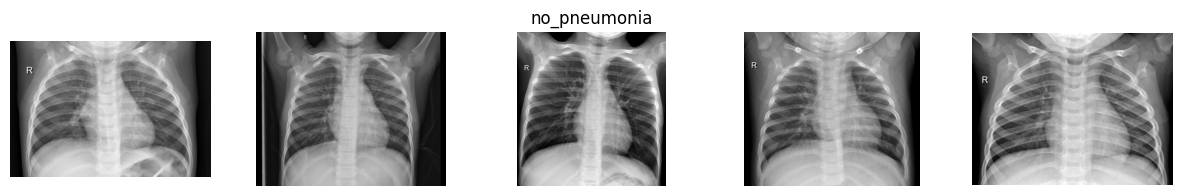

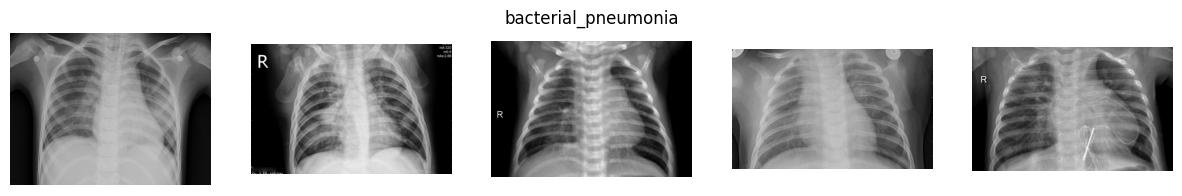

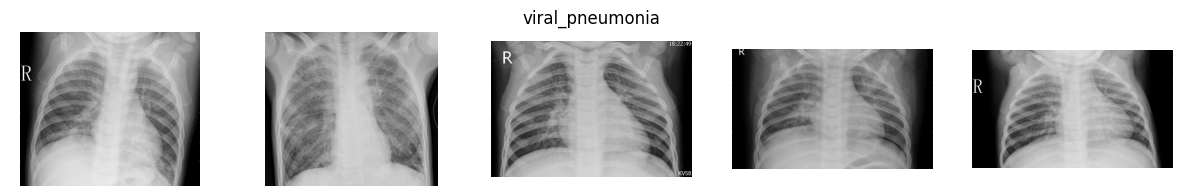

In [45]:
import os
import matplotlib.pyplot as plt

# Define the base directory
base_dir = 'final_train'

# Class folder names
classes = ['no_pneumonia', 'bacterial_pneumonia', 'viral_pneumonia']

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)
    
    plt.figure(figsize=(15, 2))
    plt.title(class_name)
    plt.axis('off')

    # Display 5 sample images from each class
    for i in range(5):
        img_path = os.path.join(folder_path, os.listdir(folder_path)[i])
        img = plt.imread(img_path)
        
        plt.subplot(1, 5, i + 1)
        plt.axis('off')
        plt.imshow(img, cmap="gray")
    
    plt.show()


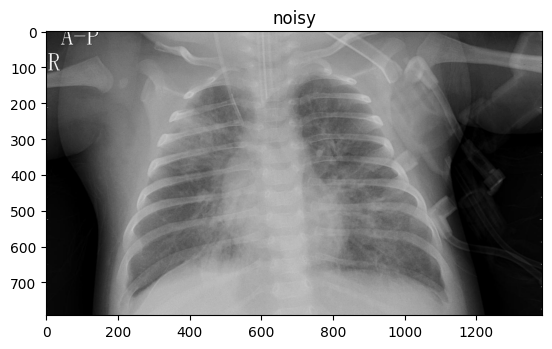

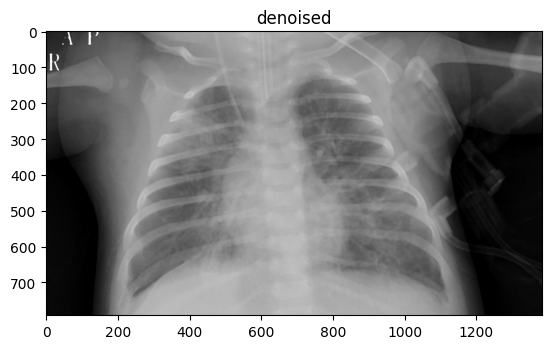

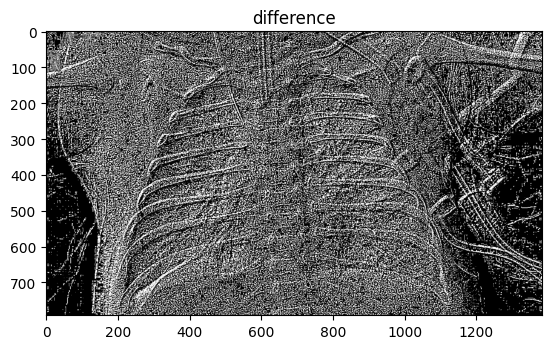

In [46]:
noisy_img = Image.open("final_train/viral_pneumonia/viral_pneumonia_100.jpg")
plt.title("noisy")
plt.imshow(noisy_img, cmap="gray")
plt.show()

filtered_img = scipy.ndimage.median_filter(noisy_img, size=6)
plt.title("denoised")
plt.imshow(filtered_img, cmap="gray")
plt.show()

diff_img = np.abs(filtered_img - noisy_img)
plt.title("difference")
plt.imshow(diff_img, cmap="gray")
plt.show()


## Preliminary plan for preprocessing
What needs fixing before modeling?

I believe the only thing left that needs fixing is the image size. Since images vary in size they will all needed to be transformed to the same size. We most likely will go with the proven 224x224 image size used in the skin lesion classification activity.

In [48]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Define the transform with resizing
transform = transforms.Compose([
    # Resize image
    transforms.Resize((224, 224)),
    # Convert image to PyTorch tensor
    transforms.ToTensor(),
    # ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# transform train_images
train_dataset = ImageFolder(root='final_train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = ImageFolder(root="test_images", transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


#################################### UN-COMMENT FOLLOWING CODE IF PULLING MODEL FROM WEB ####################################
'''
from torch import nn

num_classes = len(classes)
net = torchvision.models.resnet18(pretrained = True)

# We replace last layer of resnet to match our number of classes which is 7
net.fc = nn.Linear(512, num_classes)
net = net.to(device)
'''


Classes: ['bacterial_pneumonia', 'no_pneumonia', 'viral_pneumonia']


## ResNet Model:


In [58]:
from torch import nn
import torchvision.models as models
import torch

# Manually load the pretrained model weights
model_path = "./resnet18-f37072fd.pth"  # Make sure this path is correct
net = models.resnet18()
net.load_state_dict(torch.load(model_path))

# Replace last layer of resnet to match our number of classes
num_classes = len(classes)
net.fc = nn.Linear(512, num_classes)

# Move to device (e.g. 'cuda' or 'cpu')
net = net.to(device)


In [63]:
import torch
import torch.optim as optim

# Assuming class_weights is a dict like: {0: 1.0, 1: 2.5, ..., n: w}
# Convert it to a list or tensor in the correct order
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

# Now use it in the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(net.parameters(), lr=1e-5)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [64]:
from sklearn.metrics import accuracy_score

def get_accuracy(predicted, labels):
    batch_len, correct= 0, 0
    batch_len = labels.size(0)
    correct = (predicted == labels).sum().item()
    return batch_len, correct

def evaluate(model, val_loader):
    losses= 0
    num_samples_total=0
    correct_total=0
    model.eval()
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)
        _, predicted = torch.max(out, 1)
        loss = criterion(out, labels)
        losses += loss.item() 
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        correct_total +=corr
    accuracy = correct_total/num_samples_total
    losses = losses/len(val_loader)
    return losses, accuracy

In [67]:
# number of loops over the dataset
num_epochs = 10
accuracy = []
val_accuracy = []
losses = []
val_losses = []


for epoch in range(num_epochs):
    running_loss = 0.0
    correct_total= 0.0
    num_samples_total=0.0
    for i, data in enumerate(train_loader):
        # get the inputs
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        # set the parameter gradients to zero
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        correct_total +=corr
        running_loss += loss.item()

    
    running_loss /= len(train_loader)
    train_accuracy = correct_total/num_samples_total
    val_loss, val_acc = evaluate(net, val_loader)
    
    print('Epoch: %d' %(epoch+1))
    print('Loss: %.3f  Accuracy:%.3f' %(running_loss, train_accuracy))
    print('Validation Loss: %.3f  Val Accuracy: %.3f' %(val_loss, val_acc))

    losses.append(running_loss)
    val_losses.append(val_loss)
    accuracy.append(train_accuracy)
    val_accuracy.append(val_acc)
print('Finished Training')

Epoch: 1
Loss: 0.448  Accuracy:0.825
Validation Loss: 1.996  Val Accuracy: 0.474
Epoch: 2
Loss: 0.342  Accuracy:0.871
Validation Loss: 1.782  Val Accuracy: 0.529
Epoch: 3
Loss: 0.273  Accuracy:0.902
Validation Loss: 2.863  Val Accuracy: 0.443
Epoch: 4
Loss: 0.189  Accuracy:0.942
Validation Loss: 2.945  Val Accuracy: 0.445
Epoch: 5
Loss: 0.121  Accuracy:0.969
Validation Loss: 3.230  Val Accuracy: 0.496
Epoch: 6
Loss: 0.070  Accuracy:0.988
Validation Loss: 3.532  Val Accuracy: 0.445
Epoch: 7
Loss: 0.045  Accuracy:0.994
Validation Loss: 3.724  Val Accuracy: 0.461
Epoch: 8
Loss: 0.021  Accuracy:0.999
Validation Loss: 3.776  Val Accuracy: 0.508
Epoch: 9
Loss: 0.010  Accuracy:1.000
Validation Loss: 4.628  Val Accuracy: 0.497
Epoch: 10
Loss: 0.006  Accuracy:1.000
Validation Loss: 5.490  Val Accuracy: 0.459
Finished Training
